In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

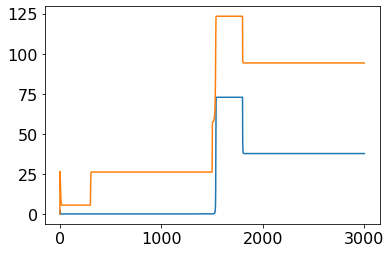

[[2.3474e-04 2.6062e+01]
 [3.7674e+01 9.4217e+01]]


In [3]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

low state vars =  [ 8.3127e-005  2.5847e+001 -3.3072e-001  1.0327e+000  0.0000e+000
  1.6420e-005  7.9023e-001  1.5346e-005  8.7951e-001  1.0135e-006
  2.5945e-003  8.8534e-007  1.9317e-003  2.3986e-264  1.7990e-264
  1.5030e+000  1.4869e+000 -7.0969e+001  2.1153e+001  2.3058e+000]


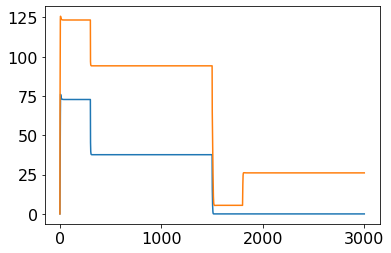

In [4]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.99

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [151]:
dur = 5.
dur_pre = 5.
dur_post = 5.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_hl = aln.getZeroTarget()
target_hl[:,0,:] = steady_rates[0,0]
target_hl[:,1,:] = steady_rates[0,1]

max_it = 10
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 50.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

#alg = "A1"
alg = "A2"

plot_only = False

init_inf_hl = control0.copy()
#init_inf_hl[:,:,:2] = -100.

init_1nA_hl = control0.copy()
#init_1nA_hl[:,:,:10] = -5.

init_inf_lh = - init_inf_hl

init_1nA_lh = - init_1nA_hl

In [158]:
# A: precision only, free choice of control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

set cost params


In [159]:
max_it = 3

if not plot_only:
    if alg == "A1":
        bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(init_inf_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlA, bestStateA, costA, runtimeA = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultA = {"Opt_control": bestControlA,
              "Opt_state": bestStateA,
              "costArray": costA,
              "runtimeArray": runtimeA,    
    }

    dump_dicts = [opt_params, aln.params, resultA]
    filename = str("A_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

True
RUN  0 , total integrated cost:  15466.74525077069
RUN  1 , total integrated cost:  1003.8134712808753
RUN  2 , total integrated cost:  700.56497527794
RUN  3 , total integrated cost:  626.0741832187623
Improved over  3  iterations by  96  percent.


In [85]:
"""
RUN  0 , total integrated cost:  15466.74525077069
RUN  1 , total integrated cost:  1003.8134712808749
RUN  2 , total integrated cost:  700.5649752779399
RUN  3 , total integrated cost:  626.0741832187625
RUN  4 , total integrated cost:  613.6475343935365
RUN  5 , total integrated cost:  609.625100127427
RUN  6 , total integrated cost:  607.80600529149
RUN  7 , total integrated cost:  607.0532545487774
RUN  8 , total integrated cost:  606.8147793531064
RUN  9 , total integrated cost:  606.7499606365028
RUN  10 , total integrated cost:  606.7316568307405
Improved over  10  iterations by  97  percent.
"""

print(runtimeA)
# step size old method
runtimeAb = runtimeA
costAb = costA

[ 2.3421826  4.8790238  7.4145163 10.2141415 12.9554314 15.7983767
 18.6522914 21.5824867 24.7556411 28.2339362 28.2386108]


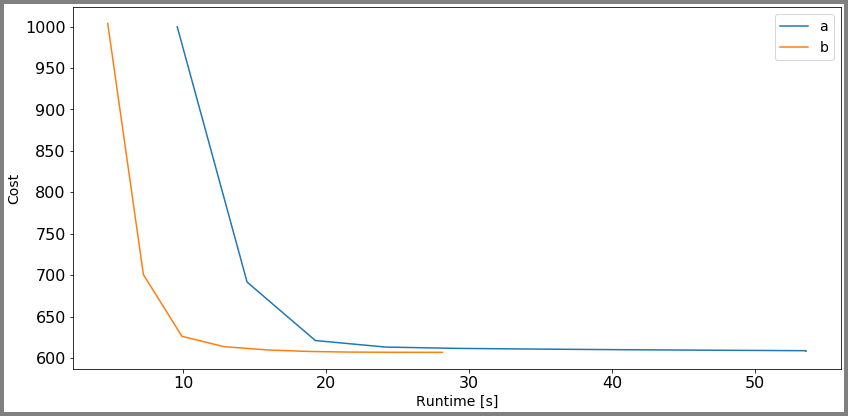

In [80]:
costArray = np.array( [costAa, costAb] )
runtimeArray = np.array( [runtimeAa, runtimeAb] )
labelArray = ["a", "b"]

#print("runtime = ", runtimeA)
#print("cost = ", costA)

plotFunc.plot_conv_runtime(runtimeArray, costArray, labelArray, path,
                           filename_ = str('p1_e0_uInf_HighLow_convergence_time_' + alg))

runtime =  [ 2.4329993  4.999063   7.5962005 10.3352572 13.1849019 15.9109071
 18.889263  22.2680817 25.2659256 28.4698313 28.4730876]
cost =  [15466.74525077  1005.25071999   700.64414892   625.58982828
   613.35796446   609.60238133   607.78289876   607.07207065
   606.84073505   606.7638678    606.74076234]


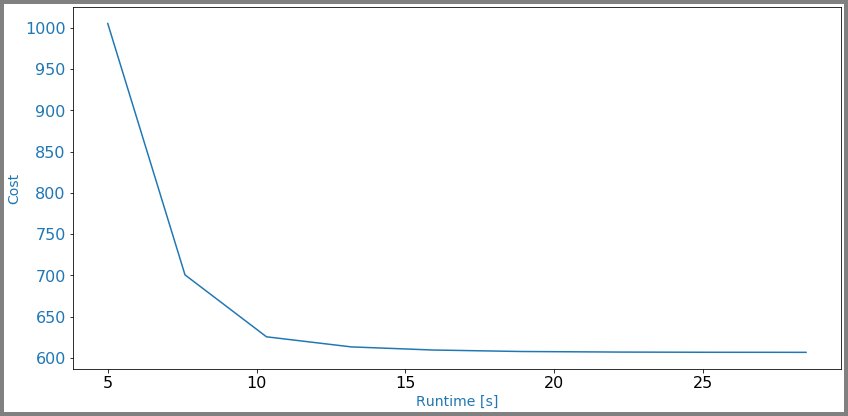

In [41]:
# step size new method
print("runtime = ", runtimeA)
print("cost = ", costA)
plotFunc.plot_conv_runtime(runtimeA, costA, path, filename_ = str('p1_e0_uInf_HighLow_convergence_time_' + alg))

In [ ]:
if not plot_only:
    plotFunc.plot_convergence(costA, path, filename_ = str('p1_e0_uInf_HighLow_cost_' + alg), ratio_ = 0.25)

In [9]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e0_uInf_HighLow_' + alg) )

In [10]:
# B: precision only, max 1nA control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

set cost params


In [11]:
if not plot_only:
    if alg == "A1":
        bestControlB, bestStateB, costB, runtimeB, grad = aln.A1(init_1nA_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlB, bestStateB, costB, runtimeB = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultB = {"Opt_control": bestControlB,
              "Opt_state": bestStateB,
              "costArray": costB,
              "runtimeArray": runtimeB,    
    }

    dump_dicts = [opt_params, aln.params, resultB]
    filename = str("B_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [12]:
if not plot_only:
    plotFunc.plot_convergence(costB, path, str("p1_e0_u1nA_HighLow_cost_" + alg))

In [13]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlB, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e0_u1nA_HighLow_' + alg) )

In [14]:
# C: precision & energy equally penalize, free choice of control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

set cost params


In [15]:
if not plot_only:
    if alg == "A1":
        bestControlC, bestStateC, costC, runtimeC, grad = aln.A1(init_inf_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlC, bestStateC, costC, runtimeC = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultC = {"Opt_control": bestControlC,
              "Opt_state": bestStateC,
              "costArray": costC,
              "runtimeArray": runtimeC,    
    }

    dump_dicts = [opt_params, aln.params, resultC]
    filename = str("C_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [16]:
if not plot_only:
    plotFunc.plot_convergence(costC, path, str("p1_e1_uInf_HighLow_cost_" + alg) )

In [17]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlC, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_uInf_HighLow_' + alg) )

In [18]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

set cost params


In [19]:
if not plot_only:
    if alg == "A1":
        bestControlD, bestStateD, costD, runtimeD, grad = aln.A1(init_1nA_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlD, bestStateD, costD, runtimeD = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultD = {"Opt_control": bestControlD,
              "Opt_state": bestStateD,
              "costArray": costD,
              "runtimeArray": runtimeD,    
    }

    dump_dicts = [opt_params, aln.params, resultD]
    filename = str("D_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [20]:
if not plot_only:
    plotFunc.plot_convergence(costD, path, str("p1_e1_u1nA_HighLow_cost_" + alg) )

In [21]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlD, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_u1nA_HighLow_' + alg))

### State switching low to high

In [22]:
# set high state rates as target
aln.params.duration = dur
max_it = 30
plot_only = False

target_lh = aln.getZeroTarget()
target_lh[:,0,:] = steady_rates[1,0]
target_lh[:,1,:] = steady_rates[1,1]        

In [23]:
# E: precision only, free choice of control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv] 

set cost params


In [24]:
if not plot_only:
    if alg == "A1":
        bestControlE, bestStateE, costE, runtimeE, grad = aln.A1(init_inf_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlE, bestStateE, costE, runtimeE = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultE = {"Opt_control": bestControlE,
              "Opt_state": bestStateE,
              "costArray": costE,
              "runtimeArray": runtimeE,    
    }      

    dump_dicts = [opt_params, aln.params, resultE]
    filename = str("E_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

True
RUN  0 , total integrated cost:  45740.55028557171
decrease bisection factor to  1.3333333333333333
restart for minimum between  [20. 10.  5.]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [26.6667 20.     15.    ]
decrease bisection factor to  0.5925925925925926
restart for minimum between  [450.432 506.736 570.078]


D:\Promotion\neurolib\neurolib\utils\func_optimize.py:240: RuntimeWarning: overflow encountered in double_scalars
  step_ /= bisec_factor_
D:\Promotion\neurolib\neurolib\utils\func_optimize.py:153: RuntimeWarning: invalid value encountered in multiply
  test_control_ = control_ + step_ * dir_


 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [20. 10.  5.]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [26.6667 20.     15.    ]
decrease bisection factor to  0.5925925925925926
restart for minimum between  [60.8186 68.4209 76.9735]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [2.5   1.25  0.625]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [1.875  1.4062 1.0547]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [5.   2.5  1.25]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [2.8125 2.1094 1.582 ]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [0.1562 0.0781 0.0391]
decrease bisection factor to  0.88888888

decrease bisection factor to  0.8888888888888888
restart for minimum between  [0.0002 0.0002 0.0001]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [0.0006 0.0003 0.0002]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [0.0005 0.0003 0.0003]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [3.0518e-04 1.5259e-04 7.6294e-05]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [1.7166e-04 1.2875e-04 9.6560e-05]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [3.0518e-04 1.5259e-04 7.6294e-05]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [0.0003 0.0002 0.0002]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [1.5259e-04 7.6

 max iteration reached, step size =  1e-323
decrease bisection factor to  1.3333333333333333
restart for minimum between  [1.1921e-06 5.9605e-07 2.9802e-07]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [6.7055e-07 5.0291e-07 3.7719e-07]
 max iteration reached, step size =  inf
RUN  1 , total integrated cost:  669.1754054286814
decrease bisection factor to  1.3333333333333333
restart for minimum between  [20. 10.  5.]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [26.6667 20.     15.    ]
decrease bisection factor to  0.5925925925925926
restart for minimum between  [30.     33.75   37.9688]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [20. 10.  5.]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [20.   15.   11.25]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minim

decrease bisection factor to  1.3333333333333333
restart for minimum between  [3.0518e-04 1.5259e-04 7.6294e-05]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [0.0003 0.0002 0.0002]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [3.0518e-04 1.5259e-04 7.6294e-05]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [0.0003 0.0002 0.0002]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [1.5259e-04 7.6294e-05 3.8147e-05]
decrease bisection factor to  0.8888888888888888
restart for minimum between  [1.5259e-04 1.1444e-04 8.5831e-05]
 max iteration reached, step size =  inf
decrease bisection factor to  1.3333333333333333
restart for minimum between  [3.0518e-04 1.5259e-04 7.6294e-05]
 max iteration reached, step size =  1e-323
decrease bisection factor to  1.3333333333333333
restart for minim

KeyboardInterrupt: 

In [ ]:
print("runtime = ", runtimeE)

plotFunc.plot_convergence(costE, path, str("p1_e0_uInf_LowHigh_cost_" + alg))

In [ ]:
plotFunc.plot_control(aln, bestControlE, dur, dur_pre, dur_post, low_state_vars, target_lh, 
             path, filename_ = str('p1_e0_uInf_LowHigh_' + alg))

In [ ]:
# F: precision only, max control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

In [ ]:
if not plot_only:
    if alg == "A1":
        bestControlF, bestStateF, costF, runtimeF, grad = aln.A1(init_1nA_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlF, bestStateF, costF, runtimeF = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultF = {"Opt_control": bestControlF,
              "Opt_state": bestStateF,
              "costArray": costF,
              "runtimeArray": runtimeF,    
    }      

    dump_dicts = [opt_params, aln.params, resultF]
    filename = str("F_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [ ]:
print("runtime = ", runtimeF)

plotFunc.plot_convergence(costF, path, str("p1_e0_u1nA_LowHigh_cost_" + alg))

In [ ]:
plotFunc.plot_control(aln, bestControlF, dur, dur_pre, dur_post, low_state_vars, target_lh,
             path, filename_ = str('p1_e0_u1nA_LowHigh_' + alg))

In [ ]:
# G: precision and energy equally, free choice of control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

In [ ]:
if not plot_only:
    if alg == "A1":
        bestControlG, bestStateG, costG, runtimeG, grad = aln.A1(init_inf_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlG, bestStateG, costG, runtimeG = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultG = {"Opt_control": bestControlG,
              "Opt_state": bestStateG,
              "costArray": costG,
              "runtimeArray": runtimeG,    
    }      

    dump_dicts = [opt_params, aln.params, resultG]
    filename = str("G_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [ ]:
print("runtime = ", runtimeG)

plotFunc.plot_convergence(costG, path, str("p1_e1_uInf_LowHigh_cost_" + alg))

In [ ]:
plotFunc.plot_control(aln, bestControlG, dur, dur_pre, dur_post, low_state_vars, target_lh, 
             path, filename_= str('p1_e1_uInf_LowHigh_' + alg))

In [ ]:
# F: precision and energy equally, max control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

In [ ]:
if not plot_only:
    if alg == "A1":
        bestControlH, bestStateH, costH, runtimeH, grad = aln.A1(init_1nA_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlH, bestStateH, costH, runtimeH = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultH = {"Opt_control": bestControlH,
              "Opt_state": bestStateH,
              "costArray": costH,
              "runtimeArray": runtimeH,    
    }      

    dump_dicts = [opt_params, aln.params, resultH]
    filename = str("H_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [ ]:
print("runtime = ", runtimeG)

plotFunc.plot_convergence(costH, path, str("p1_e1_u1nA_LowHigh_cost_" + alg))

In [ ]:
plotFunc.plot_control(aln, bestControlH, dur, dur_pre, dur_post, low_state_vars, target_lh, 
             path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg))